In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [4]:
## load and preprocess V1 data

v1_file = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_data_sfresp_at_all_ori_phase_full.pkl')

# Data at all ori/phase combos
v1 = pd.read_pickle(v1_file)
dv1 = v1.groupby(
    ['unit','ori', 'phase']
).agg(list).reset_index().drop(
    columns = ['mouse', 'section', 'cell', 'sf']
)

# nd matrix containing the data
Xv1_combos = np.array([
    np.array([np.array(y).T for y in x]) 
    for x in dv1.groupby(['ori', 'phase']).agg(list).max_norm_resp.values
])

# average across ori/phase conditions
Y_true = Xv1_combos.mean(0).transpose(0,2,1)

In [5]:
param_bounds = {
    "fts": [-200, 200],
    "t": [40, 150],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.1],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [6]:
model = SGCCircuit(param_bounds)

In [7]:
optimized_model_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'sgcc_full_population_2_28_26.pkl')
with open(optimized_model_file, 'rb') as f:
    model_state = pickle.load(f)

In [8]:
model.load_saved_parameters(model_state['final_epoch_params'])

In [9]:
R = model.predict(X)

In [10]:
param_history = model_state['param_history']

In [11]:
loss_decay = model_state['loss_decay']
last_epoch = loss_decay[-1]
best = np.where(last_epoch == last_epoch.min())[0][0]
print(f"Index of best parameters: {best}, loss = {last_epoch[best]}")

Index of best parameters: 10, loss = 0.0032787322998046875


In [12]:
x = np.arange(0.01,0.32,0.005)
y = np.exp(-x*10)
lowpass_y = np.exp(-x*10)
highpass_y = np.exp(-x*10)
lowpass_y[[np.where(x>=0.1)]] = 0
highpass_y[[np.where(x<0.1)]] = 0

meanx_lowpass = np.sum(x*lowpass_y)/np.sum(lowpass_y)
meanx = np.sum(x*y)/np.sum(y)
meanx_highpass = np.sum(x*highpass_y)/np.sum(highpass_y)

In [13]:
lowpass_y = np.exp(-x*10)
highpass_y = np.exp(-x*10)
lowpass_y[[np.where(x>=0.1)]] = 0
highpass_y[[np.where(x<0.1)]] = 0

Text(0.5, 0, 'Frequency')

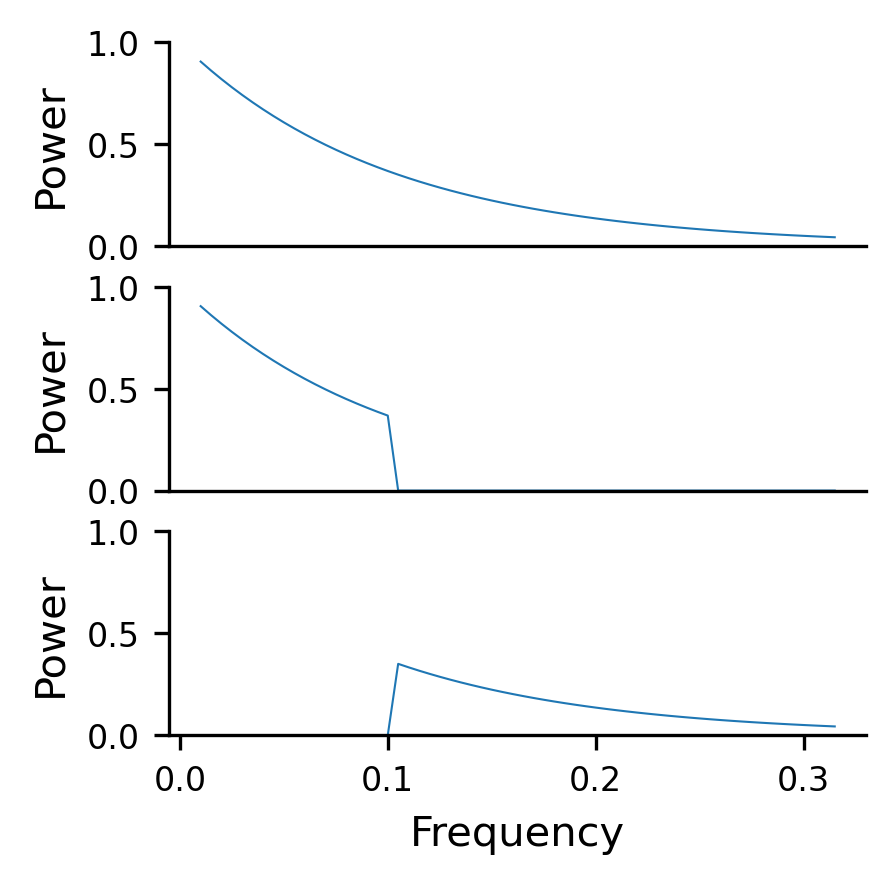

In [14]:
fig, ax = plt.subplots(3, figsize = (3,3))

for i in range(3):
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_ylabel("Power")
    ax[i].set_ylim(0,1)
    if i<2:
        ax[i].set_xticks([])

ax[0].plot(x, y, linewidth = linewidth)
ax[1].plot(x, lowpass_y, linewidth = linewidth)
ax[2].plot(x, highpass_y, linewidth = linewidth)

ax[2].set_xlabel("Frequency")

Text(0.5, 0, 'Frequency')

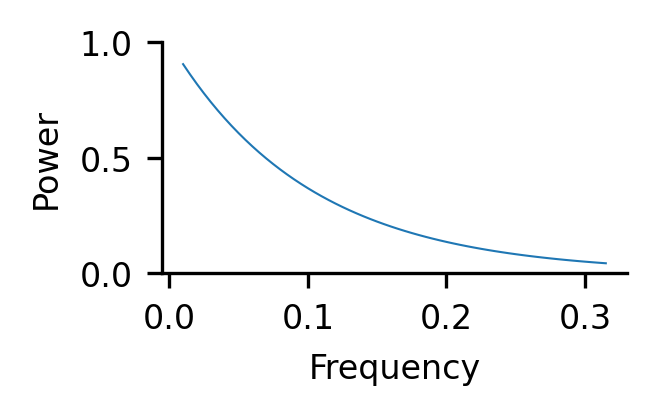

In [15]:
fig, ax = plt.subplots(1, figsize = (2,1))


ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Power", fontsize = fontsize)
ax.set_ylim(0,1)


ax.plot(x, y, linewidth = linewidth)

ax.set_xlabel("Frequency", fontsize = fontsize)

In [16]:
Rfull = model.predict(tf.convert_to_tensor(x, dtype=tf.float32))

In [17]:
NI = Rfull * tf.reshape(tf.convert_to_tensor(y, dtype = tf.float32), [1,1,-1,1])
LP = Rfull * tf.reshape(tf.convert_to_tensor(lowpass_y, dtype = tf.float32), [1,1,-1,1])
HP = Rfull * tf.reshape(tf.convert_to_tensor(highpass_y, dtype = tf.float32), [1,1,-1,1])

In [18]:
Xm = tf.convert_to_tensor([meanx_lowpass, meanx, meanx_highpass], dtype=tf.float32)

In [19]:
Rm = model.predict(Xm) 

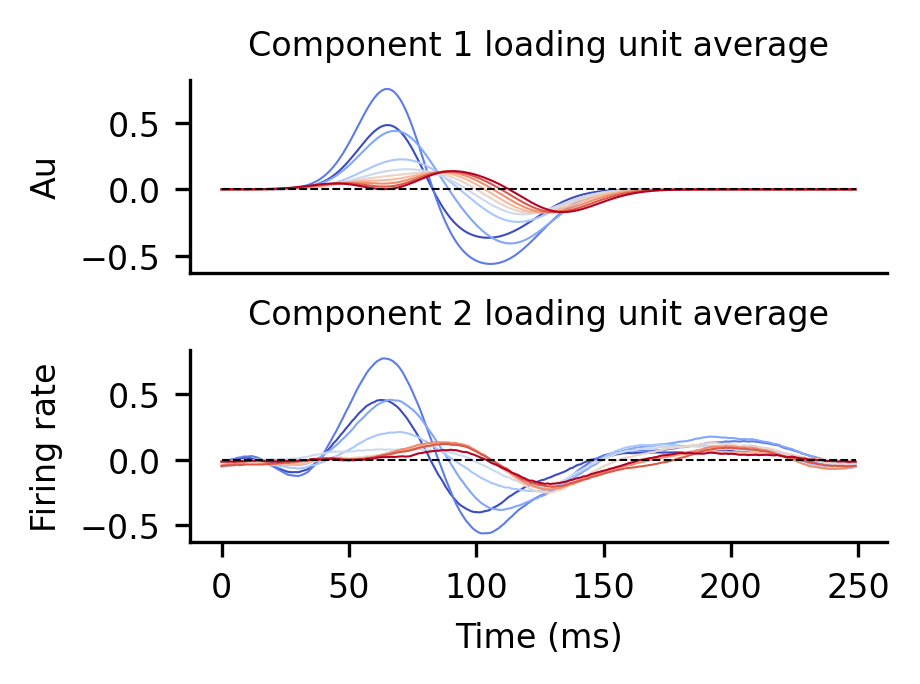

In [20]:
# neurons x SF x time steps

cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))

n = 115

fig, ax = plt.subplots(2, figsize = (3,2))
ax[0].plot(R[best].numpy()[n].T, linewidth = linewidth)
ax[0].set_title("Component 1 loading unit average", fontsize = fontsize)
ax[0].set_xticks([])

ax[1].plot(Y_true[n].T, linewidth = linewidth)
ax[1].set_title('Component 2 loading unit average', fontsize = fontsize)
for i in range(2):
    ax[i].plot(np.zeros(250), '--', color = 'black', linewidth = linewidth)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

ax[0].set_ylabel("Au", fontsize = fontsize)
ax[1].set_ylabel("Firing rate", fontsize = fontsize)
ax[1].set_xlabel("Time (ms)", fontsize = fontsize)

fig.subplots_adjust(hspace=0.4)

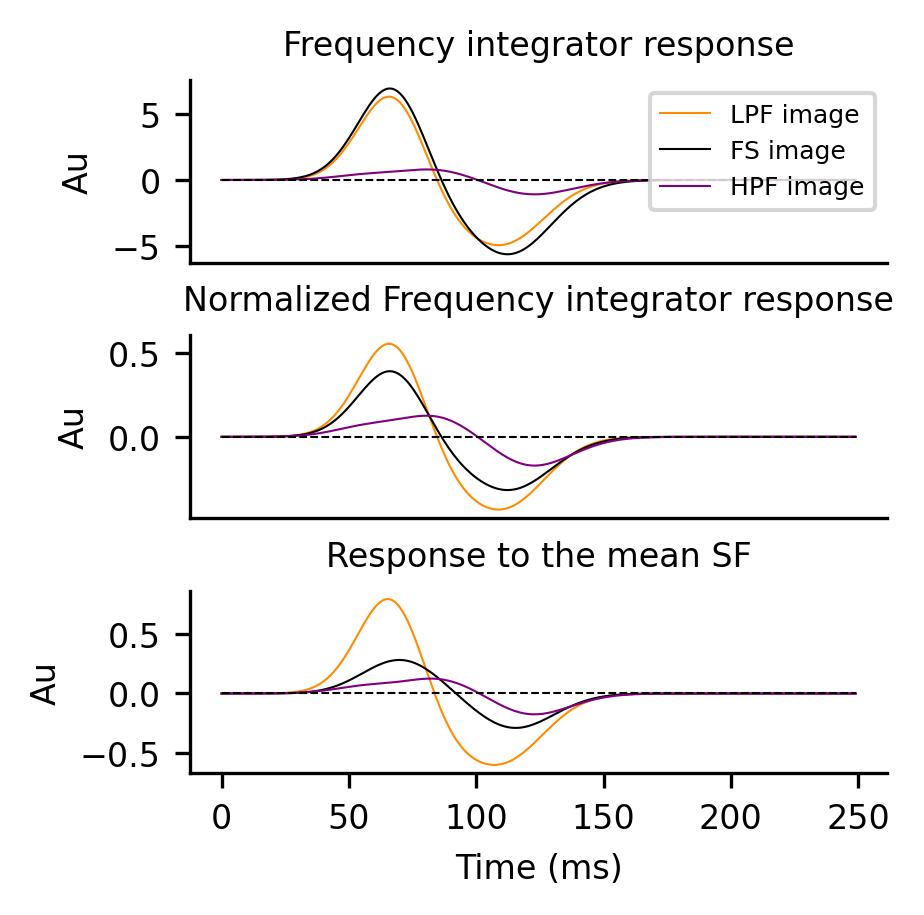

In [21]:
# neurons x SF x time steps

fig, ax = plt.subplots(3, figsize = (3,3))

ax[0].plot(tf.reduce_sum(LP[best,n], axis=0), color = 'darkorange', label = 'LPF image', linewidth = linewidth)
ax[0].plot(tf.reduce_sum(NI[best,n], axis=0), color = 'black', label = 'FS image', linewidth = linewidth)
ax[0].plot(tf.reduce_sum(HP[best,n], axis=0), color = 'purple', label = 'HPF image', linewidth = linewidth)
ax[0].set_title("Frequency integrator response", fontsize = fontsize)
ax[0].set_xticks([])

ax[1].plot(tf.reduce_sum(LP[best,n], axis=0)/lowpass_y.sum(), color = 'darkorange', label = 'LPF image', linewidth = linewidth)
ax[1].plot(tf.reduce_sum(NI[best,n], axis=0)/y.sum(), color = 'black', label = 'FS image', linewidth = linewidth)
ax[1].plot(tf.reduce_sum(HP[best,n], axis=0)/highpass_y.sum(), color = 'purple', label = 'HPF image', linewidth = linewidth)
ax[1].set_title("Normalized Frequency integrator response", fontsize = fontsize)
ax[1].set_xticks([])

ax[2].plot(Rm[best, n, 0], color = 'darkorange', linewidth = linewidth)
ax[2].plot(Rm[best, n, 1], color = 'black', linewidth = linewidth)
ax[2].plot(Rm[best, n, 2], color = 'purple', linewidth = linewidth)
ax[2].set_title('Response to the mean SF', fontsize = fontsize)

ax[0].legend(fontsize = 6, loc = 'upper right')
for i in range(3):
    ax[i].set_ylabel("Au", fontsize = fontsize)
    ax[i].plot(np.zeros(250), '--', color = 'black', linewidth = linewidth)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

ax[2].set_xlabel("Time (ms)", fontsize = fontsize)

fig.subplots_adjust(hspace=0.4)